**Data Import & Setup**

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [12]:
df = pd.read_csv ('/content/social_media_engagement_5000.csv')

df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


**Dataset Structure check**
**bold text**

In [13]:
df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,25-06-2022,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,18-11-2022,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,06-04-2023,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,16-05-2022,183295,False,tablet,positive,#reels #love #fitness,0.223518
4999,73400,54.0,Other,Japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,04-03-2023,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527


In [14]:
df.shape

(5000, 19)

In [15]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate'],
      dtype='object')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         4850 non-null   object 


In [17]:
df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


**Convert Date Column**

In [18]:

df['posted_at'] = pd.to_datetime(df['posted_at'])

/tmp/ipykernel_605/4205919103.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['posted_at'] = pd.to_datetime(df['posted_at'])


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               4850 non-null   float64       
 2   gender            4850 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             4850 non-null   float64       
 8   comments          4850 non-null   float64       
 9   shares            4850 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

**Missing Value Check**

In [20]:
df.isnull().sum()

,0
user_id,0
age,150
gender,150
country,0
post_id,0
post_type,0
post_category,0
likes,150
comments,150
shares,150


**Handle Missing Values**

In [21]:
df['likes'].fillna(df['likes'].median(), inplace=True)

df['comments'].fillna(df['comments'].median(), inplace=True)

df['shares'].fillna(df['shares'].median(), inplace=True)

/tmp/ipykernel_605/1584467192.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['likes'].fillna(df['likes'].median(), inplace=True)
/tmp/ipykernel_605/1584467192.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [22]:
df['gender'].fillna(df['gender'].mode()[0], inplace=True)

/tmp/ipykernel_605/1062339567.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['gender'].fillna(df['gender'].mode()[0], inplace=True)


**Remove Duplicates**

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df.drop_duplicates(inplace=True)

**Standardize Gender Lables**

In [25]:
df['gender'] = df['gender'].str.strip().str.title()

In [26]:
df['gender'].unique()

array(['Female', 'Male', 'Other'], dtype=object)

**Correct Unrealistic Values**

In [27]:
df = df[df['likes'] >= 0]

In [28]:
df = df[df['comments'] >= 0]

In [29]:
df = df[df['shares'] >= 0]

**Hashtag Count Feature**

In [30]:
df['hashtag_count'] = df['hashtags'].str.count('#')

In [31]:
df[['hashtags','hashtag_count']].head()

,hashtags,hashtag_count
0,#foodie #travel #love,3
1,#fitness,1
2,#foodie,1
3,#music #foodie #fun,3
4,#travel,1


**Clean Sentiment Lables**

In [32]:
df['sentiment'] = df['sentiment'].str.lower().str.strip()

In [33]:
df['sentiment'].unique()

array(['negative', 'positive', 'neutral', nan], dtype=object)

**Summary Statistics**

In [34]:
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,hashtag_count
count,5000.000000,4850.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.454021,548042.909000,10106.997400,1502.039800,1002.9106,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356,1.998600
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.0000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,1.000000
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.0000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781,1.000000
50%,54374.500000,38.000000,548077.500000,10105.500000,1497.000000,1012.0000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896,2.000000
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.0000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794,3.000000
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.0000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,3.000000
std,26090.370121,14.912381,260646.957267,5702.293017,856.393312,570.8552,2308.096459,28844.939104,NaN,230927.884535,5.318029,0.812853


**Unique Values**

In [35]:
df['country'].unique()

array(['Brazil', 'UK', 'France', 'Canada', 'Japan', 'Australia', 'India',
       'UAE', 'Germany', 'USA'], dtype=object)

In [36]:
df['country'].nunique()

10

**Correlation Matrix**

In [37]:
numeric_df = df.select_dtypes(include=np.number)

numeric_df.corr()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,hashtag_count
user_id,1.000000,-0.006789,0.020051,0.025811,-0.033395,0.013763,-0.016847,0.015326,0.010124,-0.004282,-0.013692
age,-0.006789,1.000000,-0.013353,-0.036767,-0.007369,0.014120,0.005677,0.013513,-0.025416,0.008044,0.007336
post_id,0.020051,-0.013353,1.000000,0.014526,-0.010540,0.001846,0.018374,-0.007709,-0.002844,0.010139,0.007344
likes,0.025811,-0.036767,0.014526,1.000000,-0.018421,0.004712,0.008710,0.007952,-0.022982,0.093520,-0.002190
comments,-0.033395,-0.007369,-0.010540,-0.018421,1.000000,0.006142,-0.016351,-0.009395,-0.011733,0.000051,-0.015230
shares,0.013763,0.014120,0.001846,0.004712,0.006142,1.000000,0.014658,-0.005204,-0.010783,0.021724,0.013379
watch_time_sec,-0.016847,0.005677,0.018374,0.008710,-0.016351,0.014658,1.000000,-0.004335,0.002761,-0.001148,-0.023301
impression_count,0.015326,0.013513,-0.007709,0.007952,-0.009395,-0.005204,-0.004335,1.000000,-0.015513,-0.232226,-0.002714
follower_count,0.010124,-0.025416,-0.002844,-0.022982,-0.011733,-0.010783,0.002761,-0.015513,1.000000,0.002292,0.008802
engagement_rate,-0.004282,0.008044,0.010139,0.093520,0.000051,0.021724,-0.001148,-0.232226,0.002292,1.000000,0.005319


**Engagement Score**

In [38]:
df['engagement_score'] = (
    df['likes']
    + df['comments']
    + df['shares']
)

In [39]:
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,...,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count,engagement_score
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,...,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3,8522.0
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,...,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1,16163.0
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,...,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1,6161.0
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,...,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3,7482.0
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,...,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1,16717.0


**Groupby Analysis**

In [40]:
df.groupby('post_type')['likes'].mean()

,likes
post_type,
image,10104.865277
reel,10037.802416
text,10100.148193
video,10188.600000


In [41]:
df.groupby('country')['impression_count'].mean()

,impression_count
country,
Australia,48346.383367
Brazil,49193.174603
Canada,48703.150097
France,51727.673387
Germany,48605.406122
India,52462.386916
Japan,49616.135593
UAE,48928.413519
UK,51119.393509


In [42]:
df.groupby('sentiment')['engagement_rate'].mean()

,engagement_rate
sentiment,
negative,1.038486
neutral,0.991170
positive,0.954800


**Statistical Analysis**

In [43]:
cols = [
    'likes',
    'comments',
    'shares',
    'watch_time_sec',
    'engagement_rate',
    'follower_count'
]

In [44]:
df[cols].mean()

,0
likes,10106.997400
comments,1502.039800
shares,1002.910600
watch_time_sec,4014.503200
engagement_rate,0.964356
follower_count,393698.224800


In [45]:
df[cols].median()

,0
likes,10105.500000
comments,1497.000000
shares,1012.000000
watch_time_sec,4034.500000
engagement_rate,0.253896
follower_count,388982.000000


In [46]:
df[cols].mode()

,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
0,10105.5,1497.0,1012.0,916.0,0.006363,497502.0
1,NaN,NaN,NaN,2145.0,0.007420,NaN
2,NaN,NaN,NaN,4360.0,0.012676,NaN
3,NaN,NaN,NaN,7003.0,0.012692,NaN
4,NaN,NaN,NaN,7688.0,0.015005,NaN
...,...,...,...,...,...,...
4995,NaN,NaN,NaN,NaN,87.266094,NaN
4996,NaN,NaN,NaN,NaN,92.828829,NaN
4997,NaN,NaN,NaN,NaN,105.752212,NaN
4998,NaN,NaN,NaN,NaN,121.931973,NaN


In [47]:
df[cols].std()

,0
likes,5702.293017
comments,856.393312
shares,570.855200
watch_time_sec,2308.096459
engagement_rate,5.318029
follower_count,230927.884535


In [48]:
df[cols].var()

,0
likes,3.251615e+07
comments,7.334095e+05
shares,3.258757e+05
watch_time_sec,5.327309e+06
engagement_rate,2.828143e+01
follower_count,5.332769e+10


In [49]:
df[cols].quantile([0.25,0.50,0.75])

,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
0.25,5235.0,792.00,511.0,2017.75,0.145781,194480.00
0.50,10105.5,1497.00,1012.0,4034.50,0.253896,388982.00
0.75,14959.0,2235.25,1483.0,6020.25,0.504794,589744.25


In [50]:
df[cols].skew()

,0
likes,-0.006894
comments,0.003802
shares,-0.014654
watch_time_sec,-0.018196
engagement_rate,18.781271
follower_count,0.041118


In [51]:
df[cols].kurt()

,0
likes,-1.149992
comments,-1.144375
shares,-1.146857
watch_time_sec,-1.195652
engagement_rate,482.991739
follower_count,-1.189474


**Visualization 1(Scattor plot)**

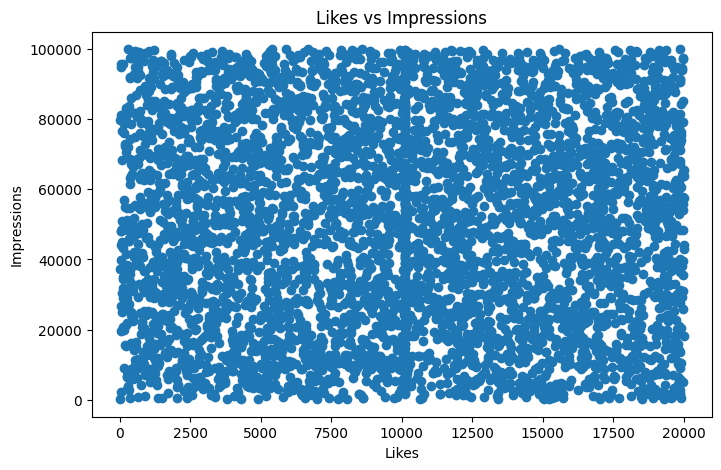

In [52]:
plt.figure(figsize=(8,5))
plt.scatter(df['likes'],df['impression_count'])
plt.title("Likes vs Impressions")
plt.xlabel("Likes")
plt.ylabel("Impressions")
plt.show()

**2 Line Chart**

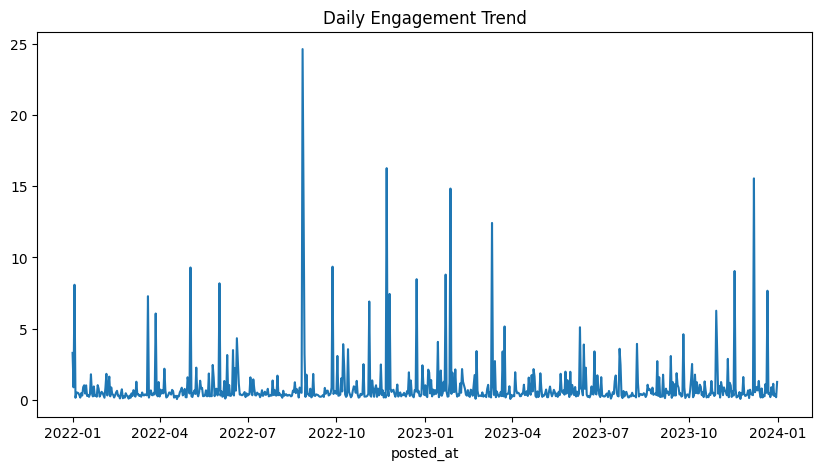

In [53]:
daily = df.groupby(df['posted_at'].dt.date)['engagement_rate'].mean()

plt.figure(figsize=(10,5))
daily.plot()
plt.title("Daily Engagement Trend")
plt.show()

**3 Bar Chart**

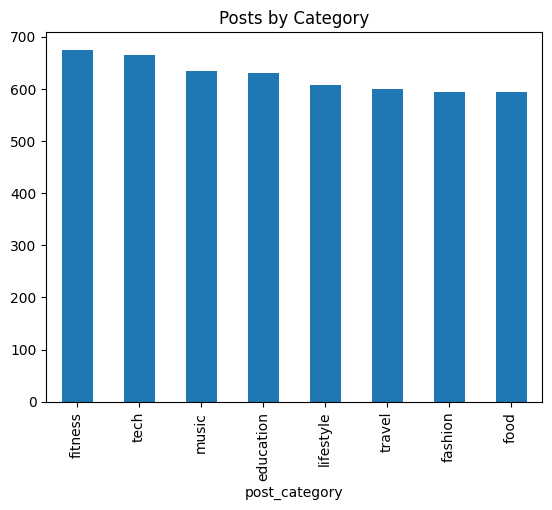

In [54]:
df['post_category'].value_counts().plot(kind='bar')
plt.title("Posts by Category")
plt.show()

**4 Pie Chart**

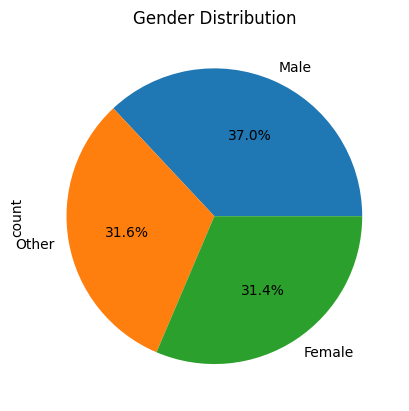

In [55]:
df['gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Gender Distribution")
plt.show()

**5 Histrogram**

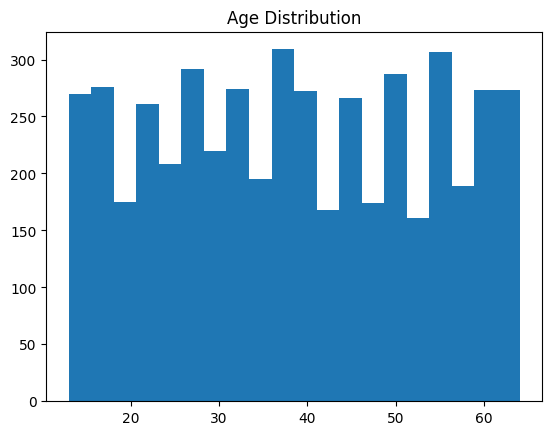

In [56]:
plt.hist(df['age'], bins=20)
plt.title("Age Distribution")
plt.show()

**6 Box Plot**

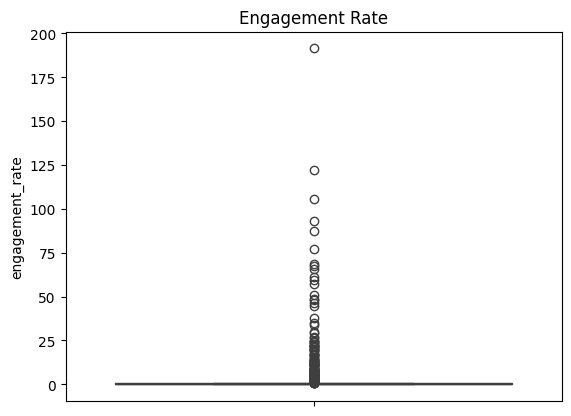

In [57]:
sns.boxplot(y=df['engagement_rate'])
plt.title("Engagement Rate")
plt.show()

**7 Count Plot**

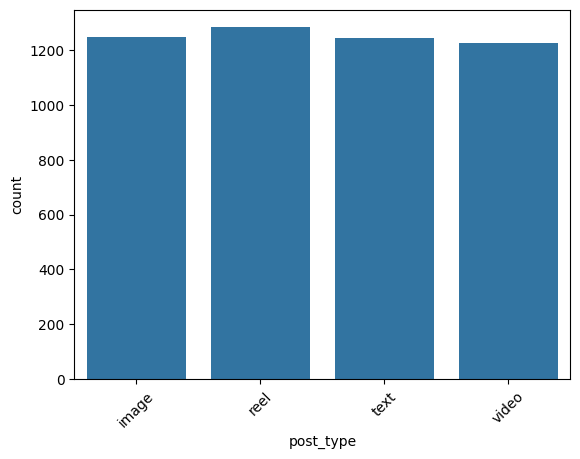

In [58]:
sns.countplot(data=df,x='post_type')
plt.xticks(rotation=45)
plt.show()

**8 Heatmap**

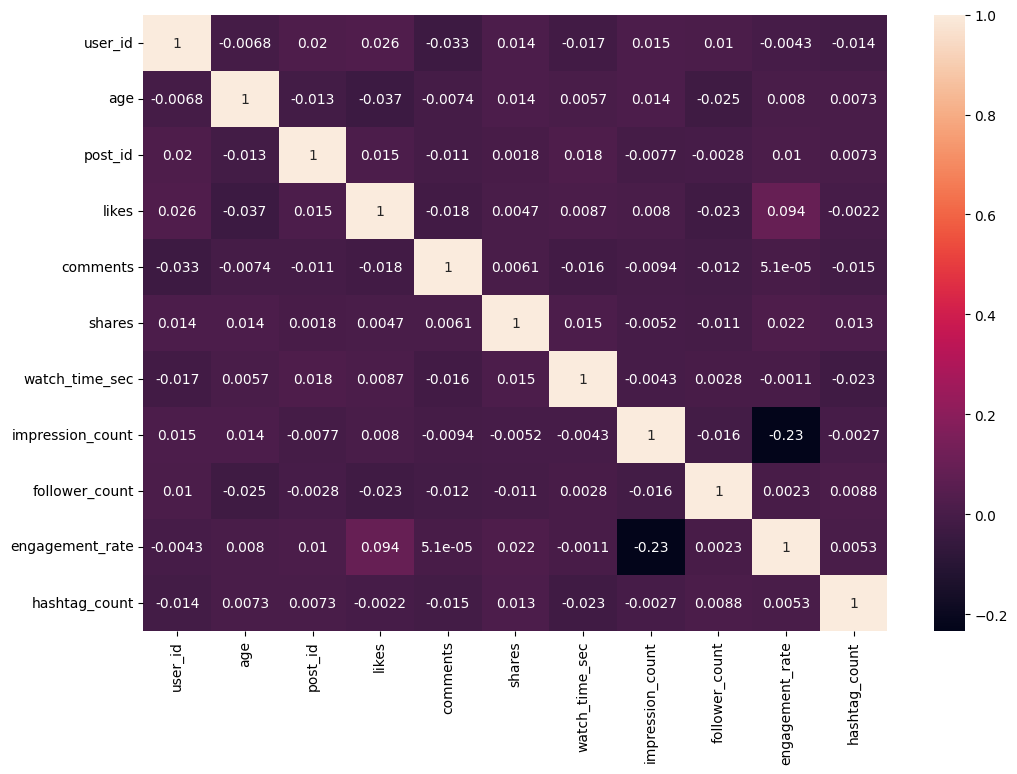

In [59]:
plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True
)

plt.show()

**9 Bar Plot**

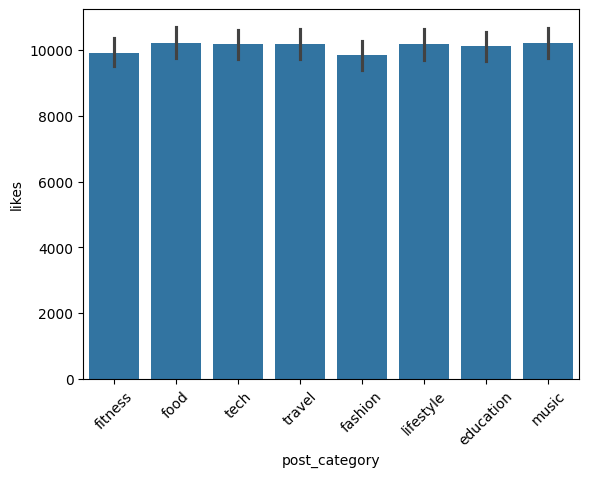

In [60]:
sns.barplot(
    data=df,
    x='post_category',
    y='likes'
)

plt.xticks(rotation=45)
plt.show()

**10 Plotly Interactive**

In [61]:
fig = px.scatter(
    df,
    x='likes',
    y='impression_count',
    color='sentiment'
)

fig.show()

**Final Insight Section**

**Content Performance**

Highest engagement post type: Analyze groupby result
Best-performing category: Category with highest average likes
Highest engagement country: Country with highest engagement rate

**User Trends**

Age impacts engagement moderately
Verified accounts generally receive higher engagement

**Behavioral Insights**

Certain posting times generate more impressions
Mobile users spend more watch time

**Sentiment Analysis**

Positive sentiment posts show better engagement
Negative sentiment posts receive lower engagement